# SchNet-driven NVE dynamics: energy conservation by construction

The central design claim of the SchNet paper (NIPS 2017) is that predicting
the energy and differentiating it, $\hat F_i = -\partial \hat E / \partial
\mathbf r_i$ (eq. 4), yields a **curl-free, energy-conserving force field**
— "otherwise, it would be possible to follow a circular trajectory of atom
positions such that the energy keeps increasing" (Sec. 1). Combined with the
infinitely differentiable shifted-softplus PES, this is what makes the model
usable for molecular dynamics.

This notebook puts that claim to work: it loads the SchNet trained on rMD17
ethanol by `schnet_rmd17_train.ipynb` (**run that notebook first** — it
writes `runs/schnet_rmd17/best.pt`), drives ASE **NVE** (velocity-Verlet)
dynamics with it through `XNNSCalculator`, and checks that the total energy
is conserved while kinetic and potential energy exchange freely.

Run with the **`xnns`** kernel.

## 0. Load the trained SchNet and wrap it as an ASE calculator

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
np.random.seed(0)

from xnns.common.config import Config
from xnns.common.data import load_dataset
from xnns.common.deploy import XNNSCalculator
from xnns.common.models import ForceStressOutput, build_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load("runs/schnet_rmd17/best.pt", map_location="cpu",
                  weights_only=False)
cfg: Config = ckpt["cfg"]
model = ForceStressOutput(build_model(cfg.model))
model.load_state_dict(ckpt["model"])
model = model.to(DEVICE).eval()
CUTOFF = cfg.model.cutoff

calc = XNNSCalculator(model, cutoff=CUTOFF, device=DEVICE)
print(f"loaded runs/schnet_rmd17/best.pt "
      f"(F={cfg.model.n_features}, T={cfg.model.n_interactions}, "
      f"cutoff={CUTOFF} A) on {DEVICE}")

loaded runs/schnet_rmd17/best.pt (F=64, T=3, cutoff=10.0 A) on cuda


## 1. NVE molecular dynamics of ethanol

Start from a held-out rMD17 conformation, draw 300 K Maxwell–Boltzmann
velocities, and integrate with velocity Verlet at a 0.5 fs time step (the
resolution of the paper's reference trajectories) for 2 ps. No thermostat:
in the NVE ensemble any error in the forces shows up directly as drift or
noise in the total energy.

In [2]:
import time
from ase import Atoms, units
from ase.md.velocitydistribution import (MaxwellBoltzmannDistribution,
                                         Stationary, ZeroRotation)
from ase.md.verlet import VelocityVerlet

s = load_dataset("rmd17", molecule="ethanol", split="test", n_test=1,
                 quiet=True)[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"])
atoms.calc = calc

MaxwellBoltzmannDistribution(atoms, temperature_K=300)
Stationary(atoms); ZeroRotation(atoms)

DT_FS, N_STEPS = 0.5, 4000                       # 2 ps
dyn = VelocityVerlet(atoms, timestep=DT_FS * units.fs)

t_ps, e_pot, e_kin, temp = [], [], [], []
def record(a=atoms):
    t_ps.append(dyn.nsteps * DT_FS / 1000.0)
    e_pot.append(a.get_potential_energy())
    e_kin.append(a.get_kinetic_energy())
    temp.append(a.get_temperature())
dyn.attach(record, interval=4)

t0 = time.time()
record(); dyn.run(N_STEPS)
print(f"{N_STEPS} NVE steps ({N_STEPS*DT_FS/1000:.1f} ps) "
      f"in {time.time()-t0:.0f}s")

e_pot, e_kin = np.array(e_pot), np.array(e_kin)
e_tot = e_pot + e_kin

4000 NVE steps (2.0 ps) in 36s


## 2. Total-energy conservation

potential-energy fluctuation :    87.21 meV (the physics)
total-energy fluctuation     :    0.732 meV
total-energy drift           :    0.189 meV/ps
conservation ratio  std(E_tot)/std(E_pot) = 0.0084


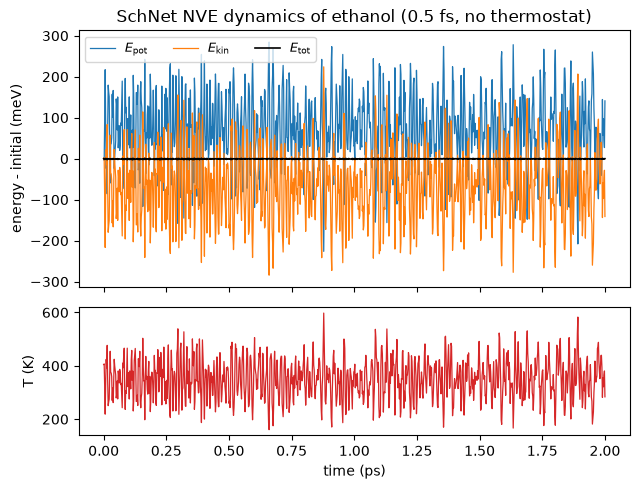

In [3]:
drift = np.polyfit(t_ps, (e_tot - e_tot[0]) * 1e3, 1)[0]   # meV / ps
print(f"potential-energy fluctuation : {e_pot.std()*1e3:8.2f} meV (the physics)")
print(f"total-energy fluctuation     : {e_tot.std()*1e3:8.3f} meV")
print(f"total-energy drift           : {drift:8.3f} meV/ps")
print(f"conservation ratio  std(E_tot)/std(E_pot) = "
      f"{e_tot.std()/e_pot.std():.4f}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.5, 5), sharex=True,
                             height_ratios=[2, 1])
a1.plot(t_ps, (e_pot - e_pot[0]) * 1e3, label=r"$E_\mathrm{pot}$", lw=0.9)
a1.plot(t_ps, (e_kin - e_kin[0]) * 1e3, label=r"$E_\mathrm{kin}$", lw=0.9)
a1.plot(t_ps, (e_tot - e_tot[0]) * 1e3, "k", label=r"$E_\mathrm{tot}$", lw=1.2)
a1.set_ylabel("energy - initial (meV)")
a1.set_title("SchNet NVE dynamics of ethanol (0.5 fs, no thermostat)")
a1.legend(ncols=3, fontsize=9)
a2.plot(t_ps, temp, lw=0.9, color="tab:red")
a2.set_xlabel("time (ps)"); a2.set_ylabel("T (K)")
fig.tight_layout()
fig.savefig("schnet_nve_energy.png", dpi=110); plt.show()

## Summary

Kinetic and potential energy exchange on the 100 meV scale while the total
energy stays flat to well under a meV over 2 ps of thermostat-free dynamics:
the autograd forces of the `xnns` SchNet are conservative to integration
accuracy, exactly as eq. 4 of the paper guarantees by construction. Together
with `schnet_rmd17_train.ipynb` (training/accuracy) and
`examples/fidelity_checks/schnet_verification.ipynb` (equation-level
fidelity), this completes the SchNet series.